# Задача 6. Компьютерное зрение: задача сегментации

* **Дедлайн**: 11.04.2025, 23:59
* **Основной полный балл**: 5
* **Максимум баллов**: 10

## Задача

Обучаем Сегментацию:
- https://colab.research.google.com/drive/1eUIOnLFB_9_6CJ3dVZxY9TV_gCqDAmaV?authuser=1#scrollTo=SjKfL5X_RbzH --- тут мы обучали на большом датасете одну эпоху.
- https://drive.google.com/file/d/11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe/view?usp=sharing --- тут лежит датасет который мы будем использовать.

Мы хотим обучить наш unet на небольшом датасете. Нужно заполнить репорт и сделать выводы.
Чтобы успеть сделать много экспериментов нужна видеокарта. Можно использовать colab, тут есть бесплатные gpu ресурсы --- так будет быстрее.


- [x] Сделать train/test split (или кросс-валидацию), зафиксировать все сиды чтобы более-менее воспроизводились результаты. Добавить метрику **jaccard index**. Переобучиться на одном батче (например 4 картинки), попробовать получить почти идеальное качество, посмотреть получилось или нет. Посчитать метрики для батча и для теста. Обучить на всем train, построить train/val кривые для loss и для **jaccard index**, подобрать оптимальное время обучения (количество шагов) для фиксированных параметров. Визуализировать topN самых плохих предсказаний.
- [x] Попробовать улучшить качество не меняя архитектуру: аугментации, гиперпараметры. Сделать test time аугментации через horizontal flip, посмотреть улучшается ли что-то.
- [x] Попробовать улучшить качество изменяя архитектуру.
- [x] *(**+2 балла**) Сделать train/test разбиение. Внутри train сделать 5fold, обучить 5 моделей. Построить кривые обучения для каждого фолда. Предсказать тест со всех 5 моделей и сагрегировать предсказания (до расчета метрик), сравнить с одной моделью обученной на всех данных. Сравнить с моделями обученными на фолдах. Сравнить плохие предсказания теста на разных фолдах. Ошибается на одних и тех же семплах или на разных?
- [ ] *(**+3 балла**) Сделать unet с pretrained энкодером (можно взять vgg или resnet18/34), сравнить с предыдущими пунктами.

Импорты и фиксирование seed

In [ ]:
import glob
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import cv2
import matplotlib.pyplot as plt
import torchvision.transforms as transforms

from sklearn.model_selection import KFold
from sklearn.model_selection import train_test_split
from IPython.display import clear_output
from torch.utils.data import Dataset

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
!pip install torchmetrics
clear_output()

In [3]:
!gdown 11wp4Bm-hEVwmZq8GmqbLpKpJiqvDSNAe
!unzip dataset.zip
clear_output()

Класс для чтения и трансформации датасета

In [ ]:
tensor_transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((256, 192)),
        transforms.ToTensor(),
    ]
)

size_transformation = transforms.Compose(
    [transforms.ToPILImage(), transforms.Resize((256, 192))]
)


class PictureDataset(Dataset):
    def __init__(self, images, masks, transform=None):
        self.images = images
        self.masks = masks
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, item):
        image_path = self.images[item]
        mask_path = self.masks[item]

        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = (mask > 0).astype(np.float32)

        if self.transform:
            image = self.transform(image)
            mask = self.transform(mask)

        return image, mask

Прочтем датасет, разделим на `train` и `test` и посмотрим на пример данных

Found pictures: 2000
Found masks: 2000
Picture size: torch.Size([3, 256, 192])
Mask size: torch.Size([1, 256, 192])


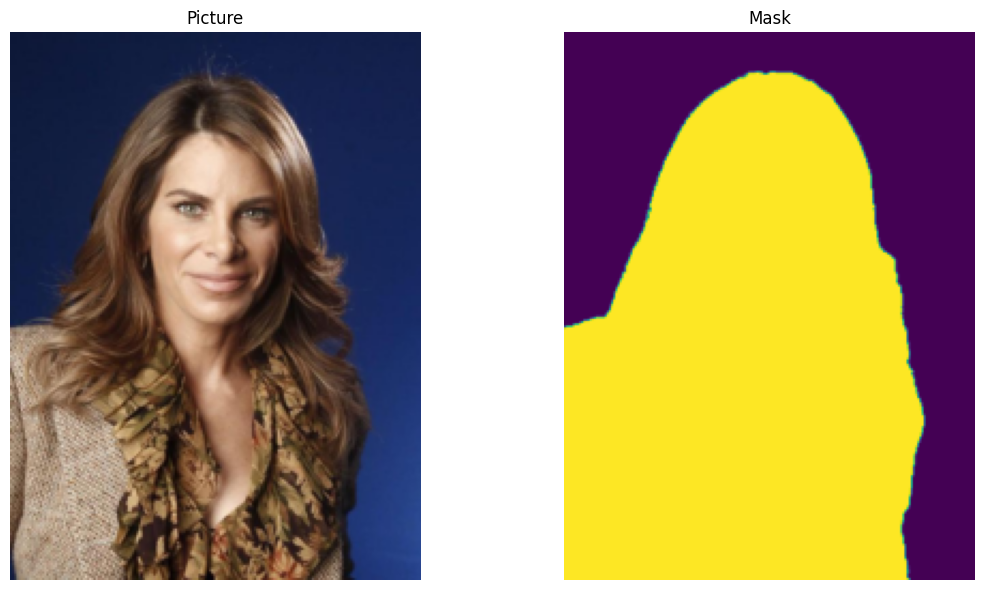

In [ ]:
image_paths = sorted(glob.glob("dataset/images/*"))
mask_paths = sorted(glob.glob("dataset/masks/*"))

print(f"Found pictures: {len(image_paths)}")
print(f"Found masks: {len(mask_paths)}")

train_images, test_images, train_masks, test_masks = train_test_split(
    image_paths, mask_paths, test_size=0.2, random_state=RANDOM_SEED
)

dataset = PictureDataset(
    images=image_paths, masks=mask_paths, transform=size_transformation
)

train_dataset = PictureDataset(
    train_images,
    train_masks,
    transform=tensor_transform,
)

test_dataset = PictureDataset(
    test_images,
    test_masks,
    transform=tensor_transform,
)

img, msk = dataset[0]
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].imshow(img)
axes[0].set_title("Picture")
axes[0].axis("off")
axes[1].imshow(msk)
axes[1].set_title("Mask")
axes[1].axis("off")
plt.tight_layout()

train_img, train_msk = train_dataset[0]
print("Picture size:", train_img.shape)
print("Mask size:", train_msk.shape)

## U-NET

In [ ]:
class CNNBlock(nn.Module):
    def __init__(
        self, in_channels, out_channels, kernel_size=3, stride=1, padding=0
    ):
        super(CNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.seq_block(x)


class CNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding):
        super(CNNBlocks, self).__init__()

        self.layers = nn.ModuleList()
        for i in range(n_conv):
            self.layers.append(CNNBlock(in_channels, out_channels, padding=padding))
            in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class Encoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(Encoder, self).__init__()

        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [
                CNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                ),
                nn.MaxPool2d(2, 2),
            ]

            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(
            CNNBlocks(
                n_conv=2,
                in_channels=in_channels,
                out_channels=out_channels,
                padding=padding,
            )
        )

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, CNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections


class Decoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(Decoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [
                nn.ConvTranspose2d(
                    in_channels, out_channels, kernel_size=2, stride=2
                ),
                CNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                ),
            ]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(
            nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0)
        )

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, CNNBlocks):
                connections_current = connections.pop(-1)
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x


class UNET(nn.Module):
    def __init__(
        self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1
    ):
        super(UNET, self).__init__()
        self.encoder = Encoder(
            in_channels, first_out_channels, padding=padding, n_down=n_down
        )
        self.decoder = Decoder(
            first_out_channels
            * (2**n_down),  # downscaled (so increase n maps 2x n_down times)
            first_out_channels
            * (
                2 ** (n_down - 1)
            ),  # we have 2x channels here, because need to concat
            exit_channels,
            padding=padding,
            n_up=n_down,
        )

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

## IOU Score

Добавим метрику jaccard index

In [ ]:
def iou_score(preds, targets, eps=1e-6):
    preds = (torch.sigmoid(preds) > 0.5).float()

    intersection = (preds * targets).sum(dim=(1, 2, 3))

    union = preds.sum(dim=(1, 2, 3)) + targets.sum(dim=(1, 2, 3)) - intersection

    iou = (intersection + eps) / (union + eps)

    return iou.mean().item()

## DataLoaders
Создадим DataLoaders для `train` и `test`, а также зафиксируем размер батча равным 4

In [8]:
from torch.utils.data import DataLoader

BATCH_SIZE = 4

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

## Вспомагательные функции

Напишем функцию для обучения модели и ее использования и функцию построения графика прогресса обучения

In [ ]:
def run_one_epoch(model, loader, optimizer, criterion, metric, training: bool):
    model.train() if training else model.eval()

    epoch_losses, epoch_metrics = [], []
    ctx = torch.enable_grad() if training else torch.no_grad()

    with ctx:
        for images, masks in loader:
            images, masks = images.to(device), masks.to(device)

            preds = model(images)
            loss = criterion(preds, masks)

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            epoch_losses.append(loss.item())
            epoch_metrics.append(metric(preds, masks))

    return np.mean(epoch_losses), np.mean(epoch_metrics)


def plot_history(history: dict):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for split, values in history["loss"].items():
        axes[0].plot(values, label=split)
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    for split, values in history["metric"].items():
        axes[1].plot(values, label=split)
    axes[1].set_title("Jaccard Index")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


def fit(
    model,
    optimizer,
    train_loader,
    val_loader,
    criterion,
    metric,
    n_epochs,
    print_history=True,
):
    history = {
        "loss": {"train": [], "val": []},
        "metric": {"train": [], "val": []},
    }

    for epoch in range(1, n_epochs + 1):
        tr_loss, tr_metric = run_one_epoch(
            model, train_loader, optimizer, criterion, metric, training=True
        )
        vl_loss, vl_metric = run_one_epoch(
            model, val_loader, optimizer, criterion, metric, training=False
        )

        history["loss"]["train"].append(tr_loss)
        history["loss"]["val"].append(vl_loss)
        history["metric"]["train"].append(tr_metric)
        history["metric"]["val"].append(vl_metric)

        clear_output(wait=True)
        print(
            f"Epoch {epoch}/{n_epochs} | "
            f"loss: {tr_loss:.4f}/{vl_loss:.4f} | "
            f"jaccard: {tr_metric:.4f}/{vl_metric:.4f}"
        )
        if print_history:
            plot_history(history)

    return history

Напишием функцию, для визуализации прогноза модели,  
где `mode`:
 - `first` - первые n_samples
 - `worst` - худшие по jaccard
 - `best`  - лучшие по jaccard

In [ ]:
@torch.no_grad()
def visualize_predictions(model, loader, n_samples=4, threshold=0.5, mode="first"):
    model.eval()

    images_all, masks_all, preds_all, scores_all = [], [], [], []

    for images, masks in loader:
        images, masks = images.to(device), masks.to(device)

        logits = model(images)
        probs = torch.sigmoid(logits)

        for i in range(len(images)):
            score = iou_score(logits[i : i + 1], masks[i : i + 1])

            images_all.append(images[i].cpu())
            masks_all.append(masks[i].cpu())
            preds_all.append(probs[i].cpu())

            scores_all.append(score.item() if torch.is_tensor(score) else score)

        if mode == "first" and len(images_all) >= n_samples:
            break

    if mode == "worst":
        order = np.argsort(scores_all)
    elif mode == "best":
        order = np.argsort(scores_all)[::-1]
    else:
        order = range(len(images_all))

    order = list(order)[:n_samples]

    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(order):
        img = images_all[idx].permute(1, 2, 0).numpy()
        pred = (preds_all[idx].squeeze() >= threshold).numpy()
        mask = masks_all[idx].squeeze().numpy()
        score = scores_all[idx]

        for j, (data, title) in enumerate(
            zip([img, pred, mask], ["Image", f"Pred (jaccard={score:.3f})", "Mask"])
        ):
            axes[row, j].imshow(data)
            axes[row, j].set_title(title)
            axes[row, j].axis("off")

    plt.tight_layout()
    plt.show()

# Переобучение на одном батче

Обучим модель на батче из 4 изображений

Epoch 30/30 | loss: 0.3815/0.8015 | jaccard: 0.9461/0.0749


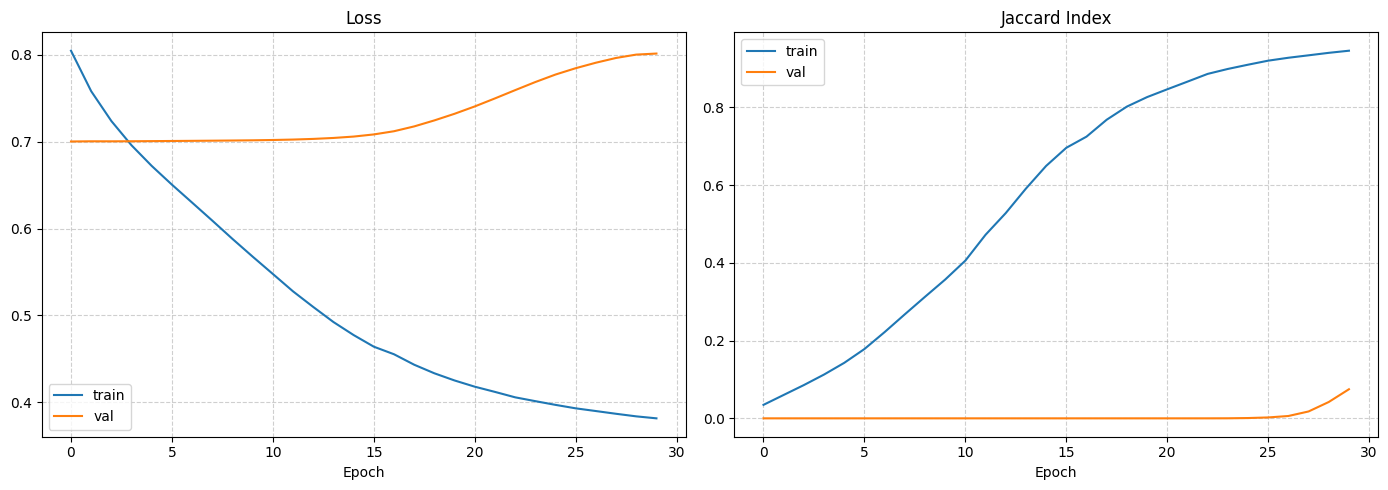

In [ ]:
single_batch_images, single_batch_masks = next(iter(train_loader))

overfit_loader = DataLoader(
    list(zip(single_batch_images, single_batch_masks)), batch_size=BATCH_SIZE
)

model_overfit = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(
    device
)
criterion_overfit = nn.BCEWithLogitsLoss()
optimizer_overfit = optim.Adam(model_overfit.parameters(), lr=3e-4)

history_overfit = fit(
    model_overfit,
    optimizer_overfit,
    overfit_loader,
    test_loader,
    criterion_overfit,
    iou_score,
    n_epochs=30,
)

На графике можно выделить следующее: train loss уверенно падает, а val loss растёт - переобучение. Jaccard на train достигает ~0.9, на val остаётся около нуля первые 25 эпох и лишь слегка поднимается к концу. Модель запомнила конкретные примеры, но не научилась обобщать.

Посмотрим на примеры лучших результатов

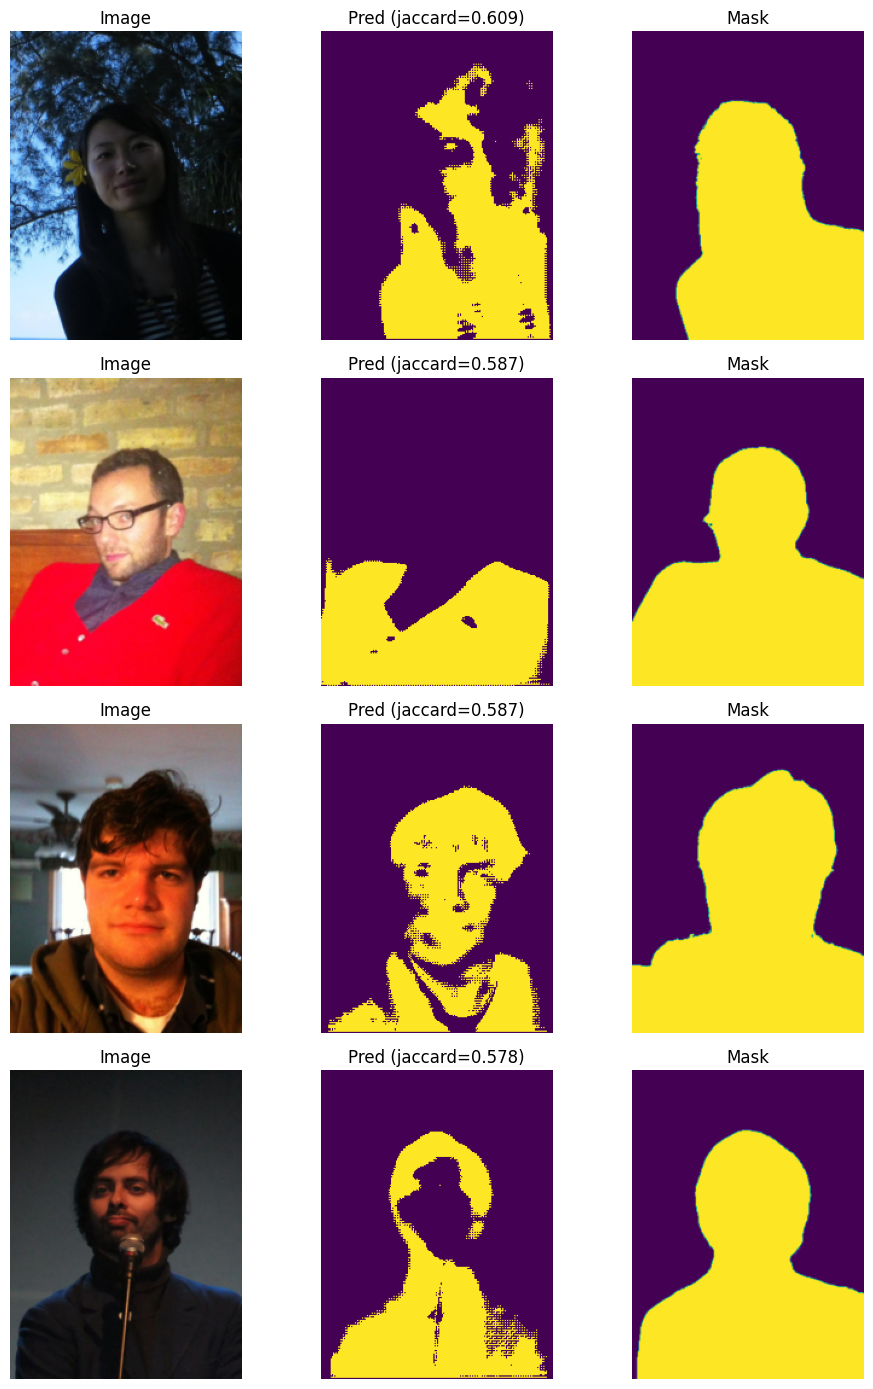

In [ ]:
visualize_predictions(model_overfit, test_loader, n_samples=4, mode="best")

Лучшие предсказания переобученной модели на тесте - jaccard 0.58–0.61. Маски грубые, с артефактами, форма силуэта угадывается лишь приблизительно.  
Также исходя из среднего jaccard можно сделать вывод, что очень много картинок, для которых модель очень плохо решила задачу.

## Обучение на всех train данных

Обучим модель на полных данных

Epoch 15/15 | loss: 0.0323/0.0747 | jaccard: 0.9764/0.9560


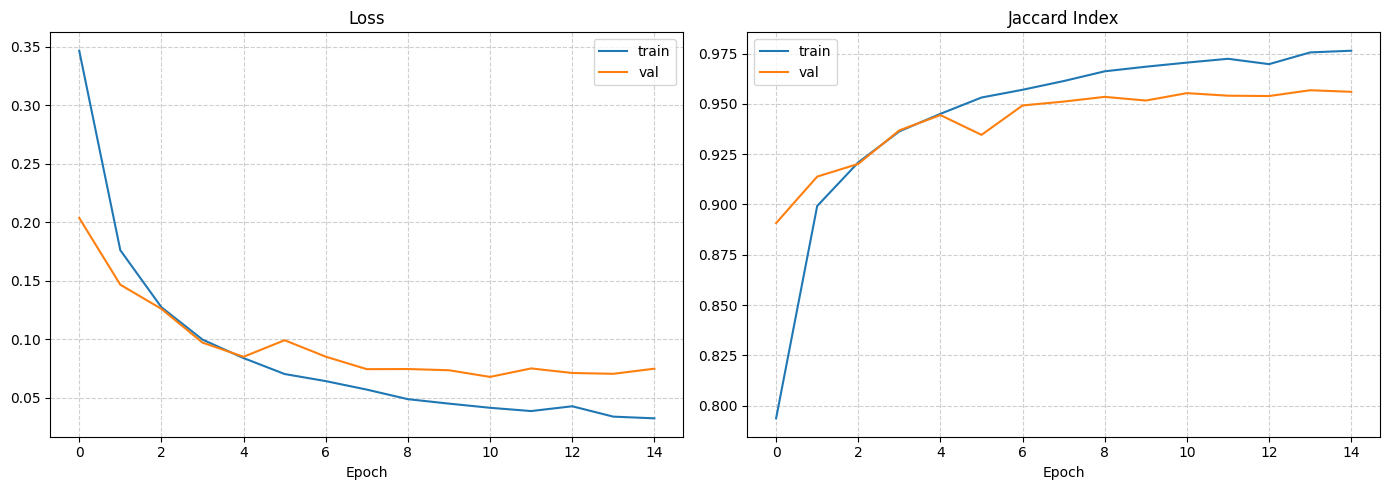

In [ ]:
model_normal = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(device)
criterion_normal = nn.BCEWithLogitsLoss()
optimizer_normal = optim.Adam(model_normal.parameters(), lr=3e-4)

history_normal = fit(
    model_normal,
    optimizer_normal,
    train_loader,
    test_loader,
    criterion_normal,
    iou_score,
    n_epochs=15,
)

Val loss стабилизируется примерно с 6-й эпохи, val jaccard выходит на плато около 0.955–0.960. Train продолжает улучшаться, небольшой gap между train и val говорит о лёгком переобучении. Оптимальное количество эпох - около 8–10.

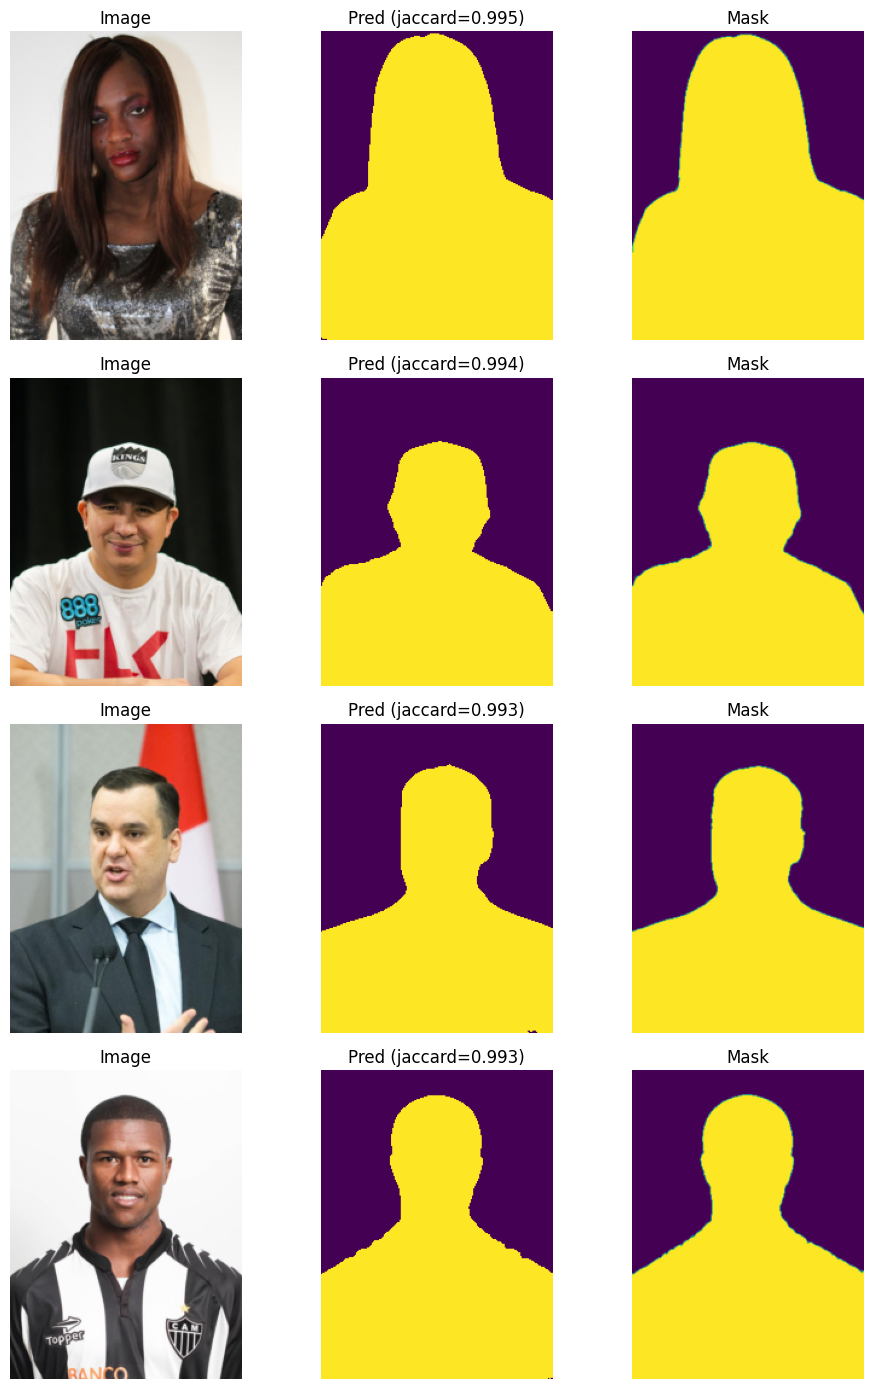

In [14]:
visualize_predictions(model_normal, test_loader, n_samples=2, mode="best")

Лучшие предсказания: jaccard 0.993-0.995, маски практически совпадают с разметкой. Модель хорошо справляется с чистыми портретными снимками на нейтральном фоне.

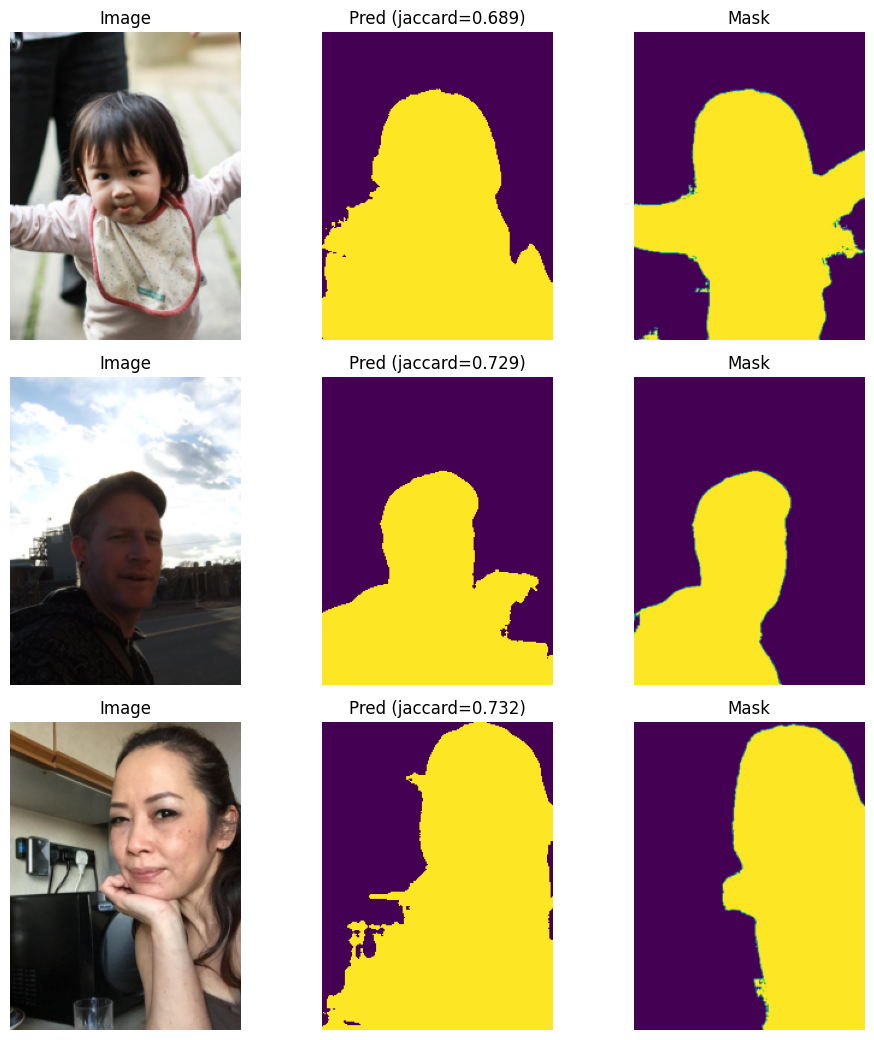

In [20]:
visualize_predictions(model_normal, test_loader, n_samples=3, mode="worst")

Худшие предсказания: jaccard 0.689-0.732. Сложные случаи - ребёнок с поднятыми руками, боковой ракурс, нестандартный фон. Модель теряет вытянутые части тела и путается на сложных контурах.

# Аугментация

Рассмотрим применение таких трансформаций, как случайные повороты. Они должны позволять бороться с переобучением модели.

In [ ]:
aug_transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((256, 192)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
    ]
)

augmented_train_dataset = PictureDataset(
    train_images, train_masks, transform=aug_transform
)

train_loader_aug = torch.utils.data.DataLoader(
    torch.utils.data.ConcatDataset([train_dataset, augmented_train_dataset]),
    batch_size=BATCH_SIZE,
    shuffle=True,
)

Epoch 8/8 | loss: 0.1470/0.0842 | jaccard: 0.9104/0.9537


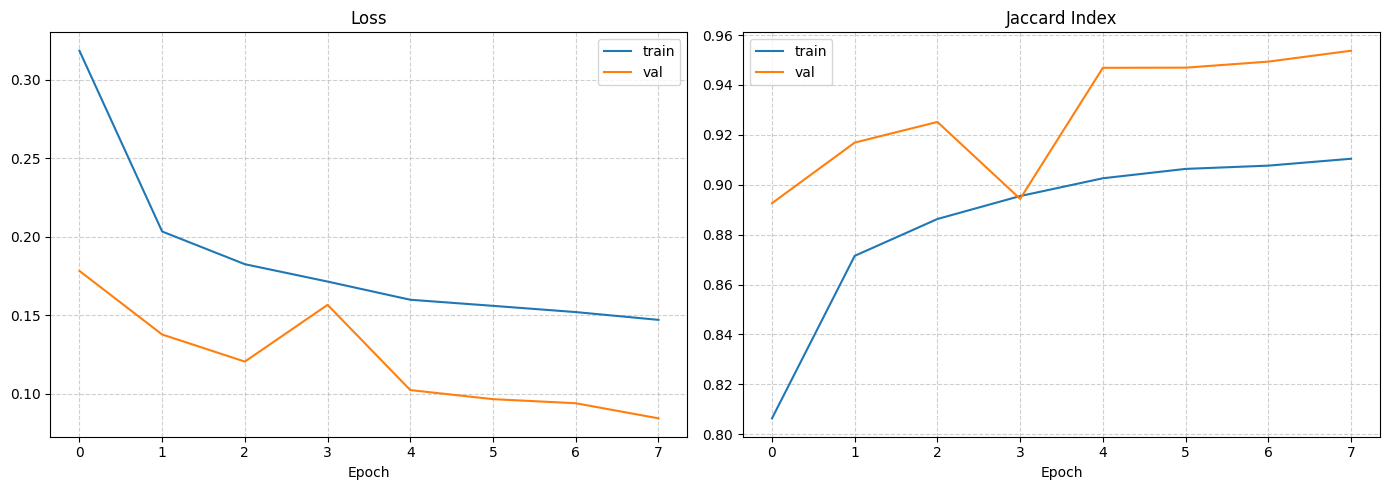

In [ ]:
model_aug = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(device)
criterion_aug = nn.BCEWithLogitsLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=3e-4)

history_aug = fit(
    model_aug,
    optimizer_aug,
    train_loader_aug,
    test_loader,
    criterion_aug,
    iou_score,
    n_epochs=8,
)

Добавление горизонтального флипа: 8 эпох, val jaccard достигает ~0.950. Val loss продолжает падать к концу, возможно стоило обучать чуть дольше. Результат сопоставим с базовой моделью, заметного улучшения нет - возможно, horizontal flip недостаточно разнообразен для этой задачи.

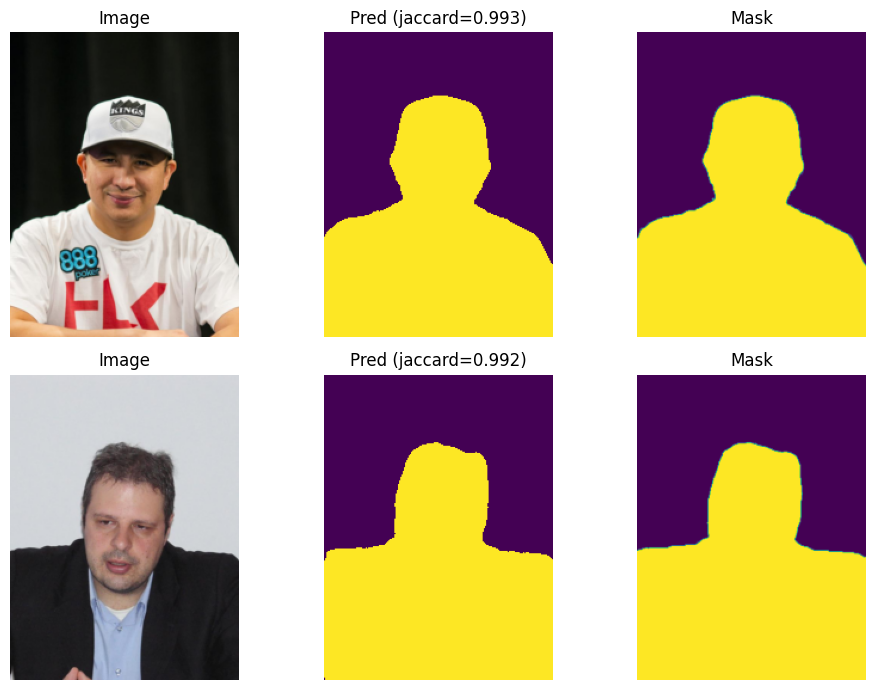

In [17]:
visualize_predictions(model_aug, test_loader, n_samples=2, mode="best")

Best predictions ~0.992–0.993 - на уровне базовой модели.

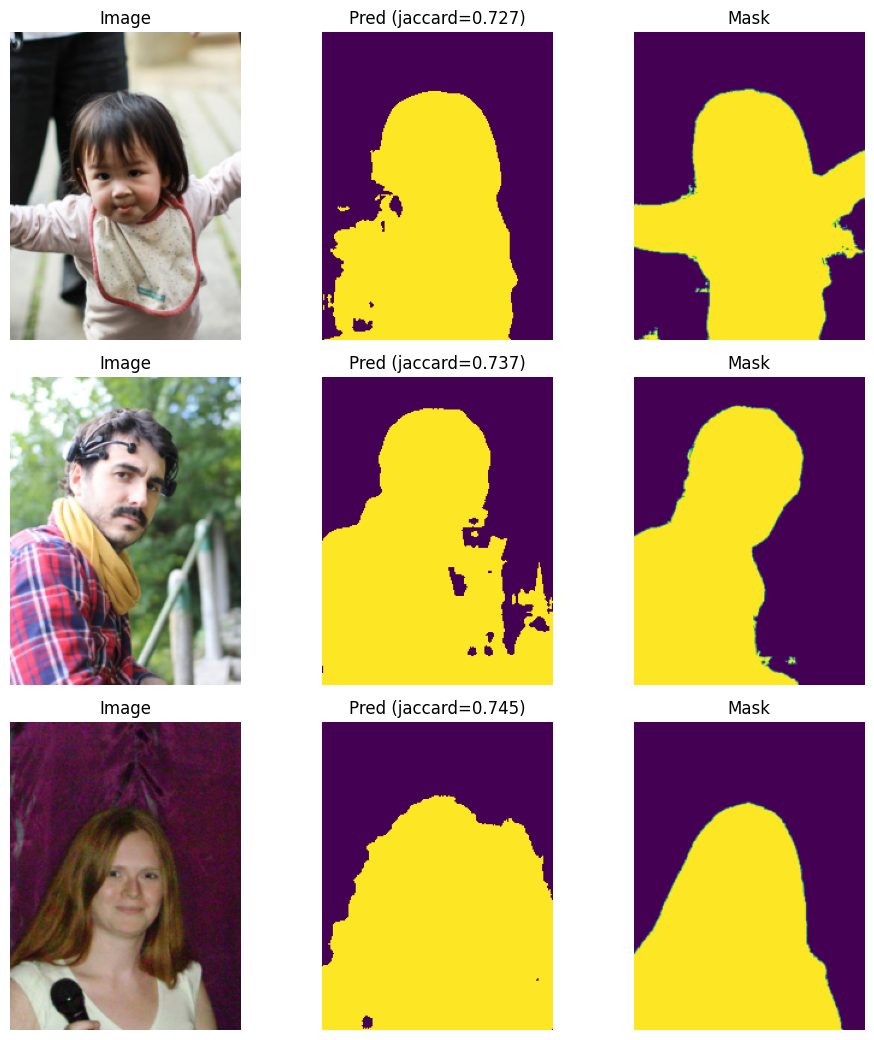

In [18]:
visualize_predictions(model_aug, test_loader, n_samples=3, mode="worst")

Худшие случаи: jaccard 0.727–0.745. Те же проблемные паттерны - ребёнок с руками, сложный фон, нестандартные позы. Аугментация немного помогла на этих примерах (самые низкие значения стали больше), но не сильно.

# Улучшения архитектуры

Попробуем два изменения:
1. Добавим Dropout после каждого свёрточного блока, чтобы снизить переобучение
2. Увеличим `first_out_channels` с 16 до 24, чтобы дать модели чуть больше ёмкости.

In [ ]:
class NewCNNBlock(nn.Module):
    def __init__(
        self,
        in_channels,
        out_channels,
        kernel_size=3,
        stride=1,
        padding=0,
        dropout=0.2,
    ):
        super(NewCNNBlock, self).__init__()

        self.seq_block = nn.Sequential(
            nn.Conv2d(
                in_channels, out_channels, kernel_size, stride, padding, bias=False
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),
        )

    def forward(self, x):
        return self.seq_block(x)


class NewCNNBlocks(nn.Module):
    def __init__(self, n_conv, in_channels, out_channels, padding, dropout):
        super(NewCNNBlocks, self).__init__()

        self.layers = nn.ModuleList()
        for i in range(n_conv):
            self.layers.append(
                NewCNNBlock(
                    in_channels, out_channels, padding=padding, dropout=dropout
                )
            )
            in_channels = out_channels

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


class NewEncoder(nn.Module):
    def __init__(self, in_channels, out_channels, padding, n_down=4):
        super(NewEncoder, self).__init__()

        self.enc_layers = nn.ModuleList()
        for _ in range(n_down):
            self.enc_layers += [
                NewCNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                    dropout=0.2,
                ),
                nn.MaxPool2d(2, 2),
            ]

            in_channels = out_channels
            out_channels = 2 * out_channels

        self.enc_layers.append(
            NewCNNBlocks(
                n_conv=2,
                in_channels=in_channels,
                out_channels=out_channels,
                padding=padding,
                dropout=0.3,
            )
        )

    def forward(self, x):
        connections = []
        for layer in self.enc_layers:
            if isinstance(layer, NewCNNBlocks):
                x = layer(x)
                connections.append(x)
            else:
                x = layer(x)
        return x, connections


class NewDecoder(nn.Module):
    def __init__(self, in_channels, out_channels, exit_channels, padding, n_up=4):
        super(NewDecoder, self).__init__()

        self.exit_channels = exit_channels
        self.layers = nn.ModuleList()

        for i in range(n_up):
            self.layers += [
                nn.ConvTranspose2d(
                    in_channels, out_channels, kernel_size=2, stride=2
                ),
                NewCNNBlocks(
                    n_conv=2,
                    in_channels=in_channels,
                    out_channels=out_channels,
                    padding=padding,
                    dropout=0.1,
                ),
            ]

            in_channels //= 2
            out_channels //= 2

        self.layers.append(
            nn.Conv2d(in_channels, self.exit_channels, kernel_size=1, padding=0)
        )

    def forward(self, x, connections):
        connections.pop(-1)
        for layer in self.layers:
            if isinstance(layer, NewCNNBlocks):
                connections_current = connections.pop(-1)
                x = torch.cat([x, connections_current], dim=1)
                x = layer(x)
            else:
                x = layer(x)
        return x


class NewUNET(nn.Module):
    def __init__(
        self, in_channels, first_out_channels, exit_channels, n_down=4, padding=1
    ):
        super(NewUNET, self).__init__()
        self.encoder = NewEncoder(
            in_channels, first_out_channels, padding=padding, n_down=n_down
        )
        self.decoder = NewDecoder(
            first_out_channels
            * (2**n_down),  # downscaled (so increase n maps 2x n_down times)
            first_out_channels
            * (
                2 ** (n_down - 1)
            ),  # we have 2x channels here, because need to concat
            exit_channels,
            padding=padding,
            n_up=n_down,
        )

    def forward(self, x):
        enc_out, connections = self.encoder(x)
        return self.decoder(enc_out, connections)

Epoch 10/10 | loss: 0.1122/0.0858 | jaccard: 0.9243/0.9415


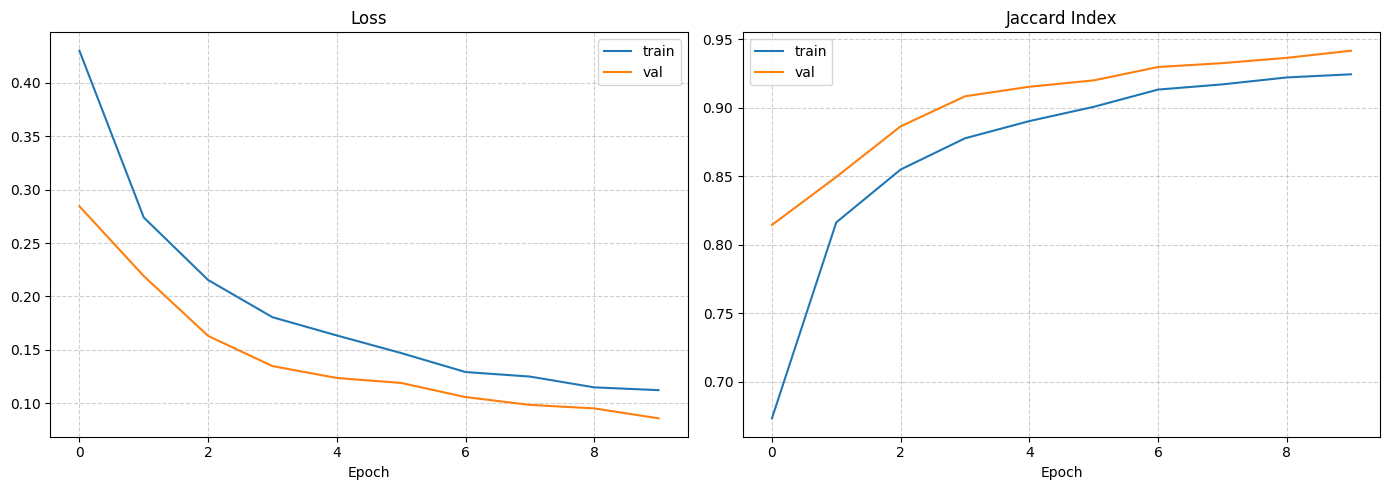

In [ ]:
model_new = NewUNET(in_channels=3, first_out_channels=24, exit_channels=1).to(device)
criterion_new = nn.BCEWithLogitsLoss()
optimizer_new = optim.Adam(model_new.parameters(), lr=3e-4)

history_aug = fit(
    model_new,
    optimizer_new,
    train_loader,
    test_loader,
    criterion_new,
    iou_score,
    n_epochs=10,
)

Новая архитектура с dropout: val jaccard ~0.940. Val loss и jaccard продолжают улучшаться к концу - модель ещё не сошлась, можно обучать дольше, но Dropout замедлил обучение по сравнению с базовой моделью.

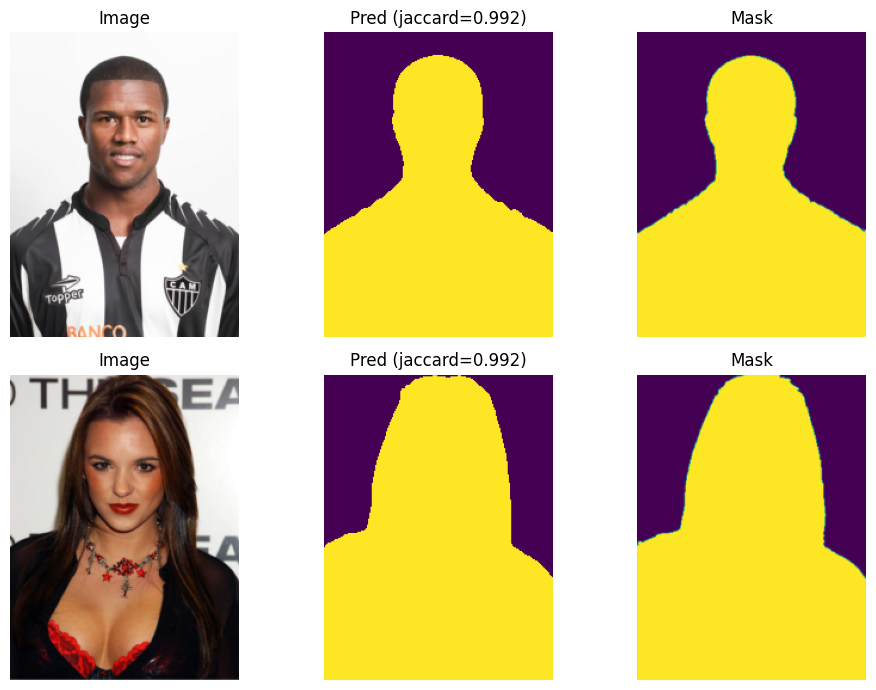

In [24]:
visualize_predictions(model_new, test_loader, n_samples=2, mode='best')

Best: ~0.992 - на уровне предыдущих моделей.

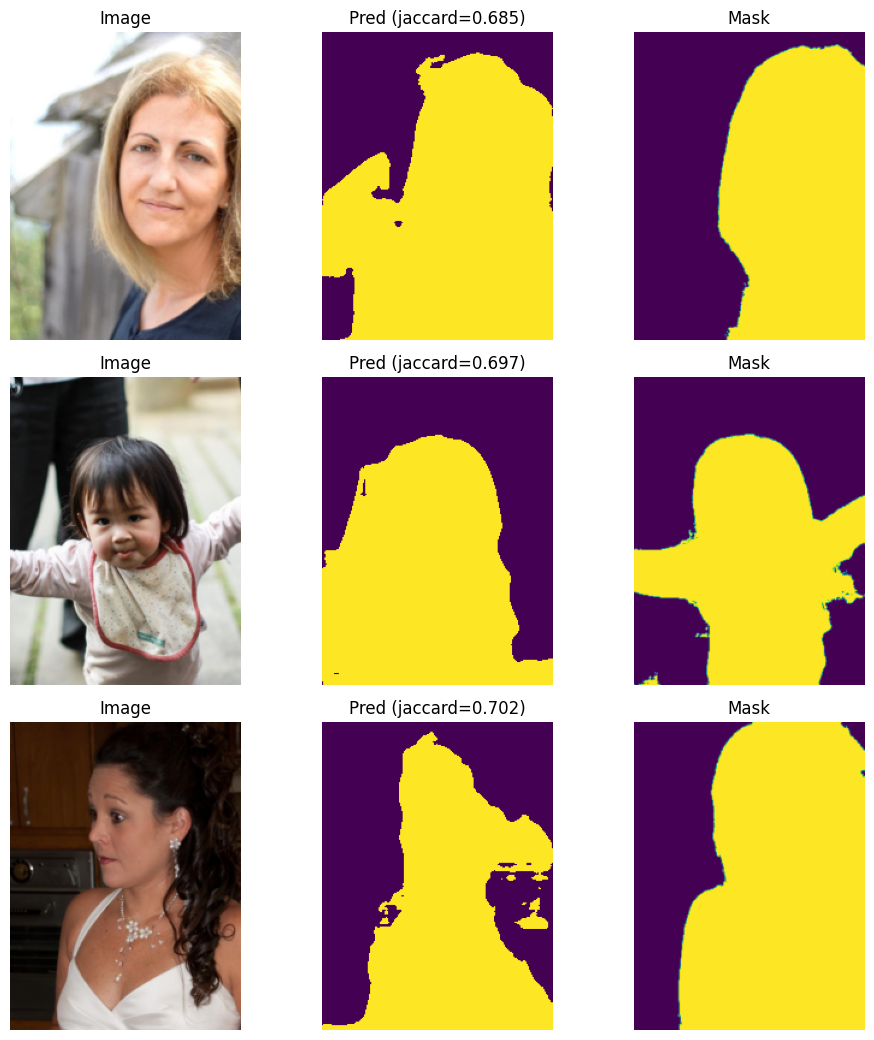

In [25]:
visualize_predictions(model_new, test_loader, n_samples=3, mode='worst')

Худшие: 0.685-0.702. Снова ребёнок с руками и сложные ракурсы. Характер ошибок похож на предыдущие модели.

# 5-Fold обучение

Разобьём train на 5 фолдов и обучим отдельную модель на каждом.  
Это позволит оценить стабильность обучения и затем объединить предсказания в 'ансамбль'.

In [ ]:
N_FOLDS = 5
kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_SEED)

fold_models = []
fold_histories = []

train_indices = np.arange(len(train_dataset))

for fold, (tr_idx, val_idx) in enumerate(kfold.split(train_indices)):
    print(f"\n========== Fold {fold+1}/{N_FOLDS} ==========")

    fold_train = DataLoader(
        torch.utils.data.Subset(train_dataset, tr_idx),
        batch_size=BATCH_SIZE,
        shuffle=True,
    )
    fold_val = DataLoader(
        torch.utils.data.Subset(train_dataset, val_idx),
        batch_size=BATCH_SIZE,
        shuffle=False,
    )

    fold_model = UNET(in_channels=3, first_out_channels=16, exit_channels=1).to(
        device
    )
    fold_criterion = nn.BCEWithLogitsLoss()
    fold_optimizer = optim.Adam(fold_model.parameters(), lr=3e-4)

    history = fit(
        fold_model,
        fold_optimizer,
        fold_train,
        fold_val,
        fold_criterion,
        iou_score,
        n_epochs=5,
        print_history=False,
    )

    fold_models.append(fold_model)
    fold_histories.append(history)

Epoch 5/5 | loss: 0.0975/0.0984 | jaccard: 0.9366/0.9344


### Кривые для каждого fold

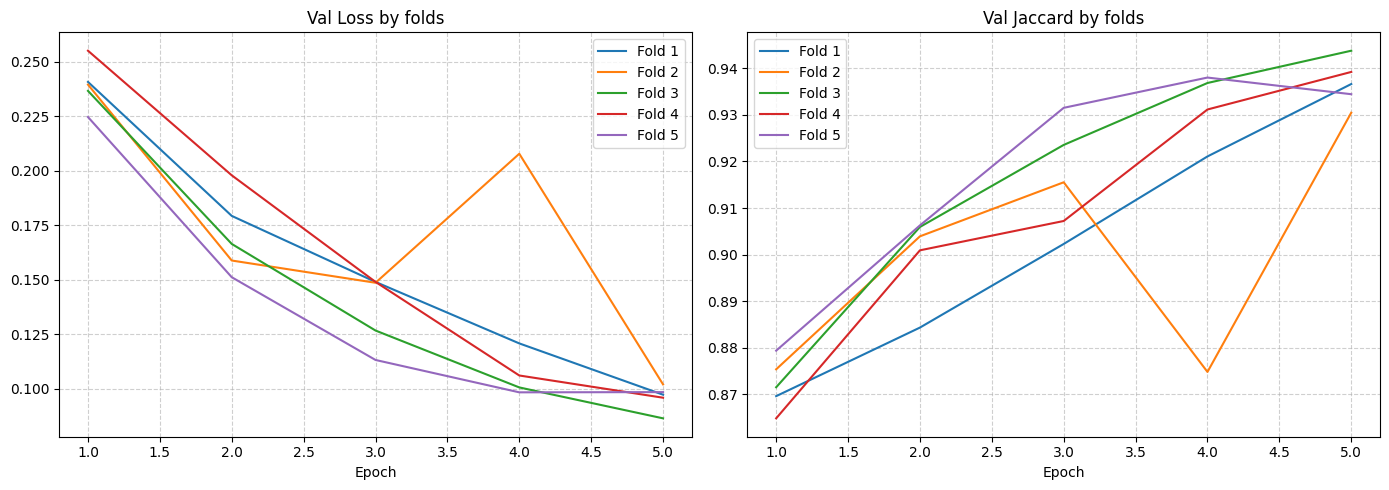

In [ ]:
def plot_fold_histories(fold_histories):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    for fold, history in enumerate(fold_histories):
        epochs = range(1, len(history["loss"]["train"]) + 1)
        axes[0].plot(epochs, history["loss"]["val"], label=f"Fold {fold+1}")
        axes[1].plot(epochs, history["metric"]["val"], label=f"Fold {fold+1}")

    axes[0].set_title("Val Loss by folds")
    axes[0].set_xlabel("Epoch")
    axes[0].legend()
    axes[0].grid(True, linestyle="--", alpha=0.6)

    axes[1].set_title("Val Jaccard by folds")
    axes[1].set_xlabel("Epoch")
    axes[1].legend()
    axes[1].grid(True, linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()


plot_fold_histories(fold_histories)

Val jaccard у всех фолдов в диапазоне 0.87–0.94 к последней эпохе, разброс умеренный. Fold 2 показывает скачок на 4-й эпохе - скорее всего, в его val-части попались нетипичные примеры. В целом фолды ведут себя похоже.

### Агрегация предсказаний

In [ ]:
@torch.no_grad()
def predict_all(model, loader):
    model.eval()
    logits_all, masks_all = [], []
    for images, masks in loader:
        images = images.to(device)
        logits_all.append(model(images).cpu())
        masks_all.append(masks)
    return torch.cat(logits_all), torch.cat(masks_all)


# Predictions of each fold model
logit_preds = []
for fold_model in fold_models:
    logits, test_masks_all = predict_all(fold_model, test_loader)
    logit_preds.append(logits)

# Aggregation - average over all folds
ensemble_preds = torch.stack(logit_preds).mean(dim=0)

# Predictions of the model trained on all data
single_logits, _ = predict_all(model_normal, test_loader)

## Сравнение метрик

In [ ]:
print("=== Jaccard on test ===")
for i, logits in enumerate(logit_preds):
    score = iou_score(logits, test_masks_all)
    print(f"  Fold {i+1}: {score:.4f}")

ensemble_score = iou_score(ensemble_preds, test_masks_all)
single_score = iou_score(single_logits, test_masks_all)

print(f"  Ensemble (mean of 5 folds): {ensemble_score:.4f}")
print(f"  Single model (all train):   {single_score:.4f}")

=== Jaccard on test ===
  Fold 1: 0.9351
  Fold 2: 0.9355
  Fold 3: 0.9421
  Fold 4: 0.9369
  Fold 5: 0.9374
  Ensemble (mean of 5 folds): 0.9500
  Single model (all train):   0.9560


Вычислим jaccard для каждой выборки

In [ ]:
def get_sample_scores(logits, masks, eps=1e-6):
    preds = (torch.sigmoid(logits) > 0.5).float()
    intersection = (preds * masks).sum(dim=(1, 2, 3))
    union = preds.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - intersection
    return ((intersection + eps) / (union + eps)).numpy()


fold_sample_scores = [get_sample_scores(l, test_masks_all) for l in logit_preds]
ensemble_sample_scores = get_sample_scores(ensemble_preds, test_masks_all)
single_sample_scores = get_sample_scores(single_logits, test_masks_all)

Функция для визуализации худших результатов из ансабля

In [33]:
def visualize_from_tensors(images, masks, logits, sample_scores, n_samples=5, mode='worst', threshold=0.5):
    if mode == 'worst':
        order = np.argsort(sample_scores)
    elif mode == 'best':
        order = np.argsort(sample_scores)[::-1]
    else:
        order = np.arange(len(sample_scores))

    order = list(order)[:n_samples]
    probs = torch.sigmoid(logits)

    fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    for row, idx in enumerate(order):
        img   = images[idx].permute(1, 2, 0).numpy()
        pred  = (probs[idx].squeeze() >= threshold).numpy()
        mask  = masks[idx].squeeze().numpy()
        score = sample_scores[idx]

        for j, (data, title) in enumerate(zip(
            [img, pred, mask],
            ['Image', f'Pred (jaccard={score:.3f})', 'Mask']
        )):
            axes[row, j].imshow(data)
            axes[row, j].set_title(title)
            axes[row, j].axis('off')

    plt.tight_layout()
    plt.show()

### Худшие результаты в ансамбле

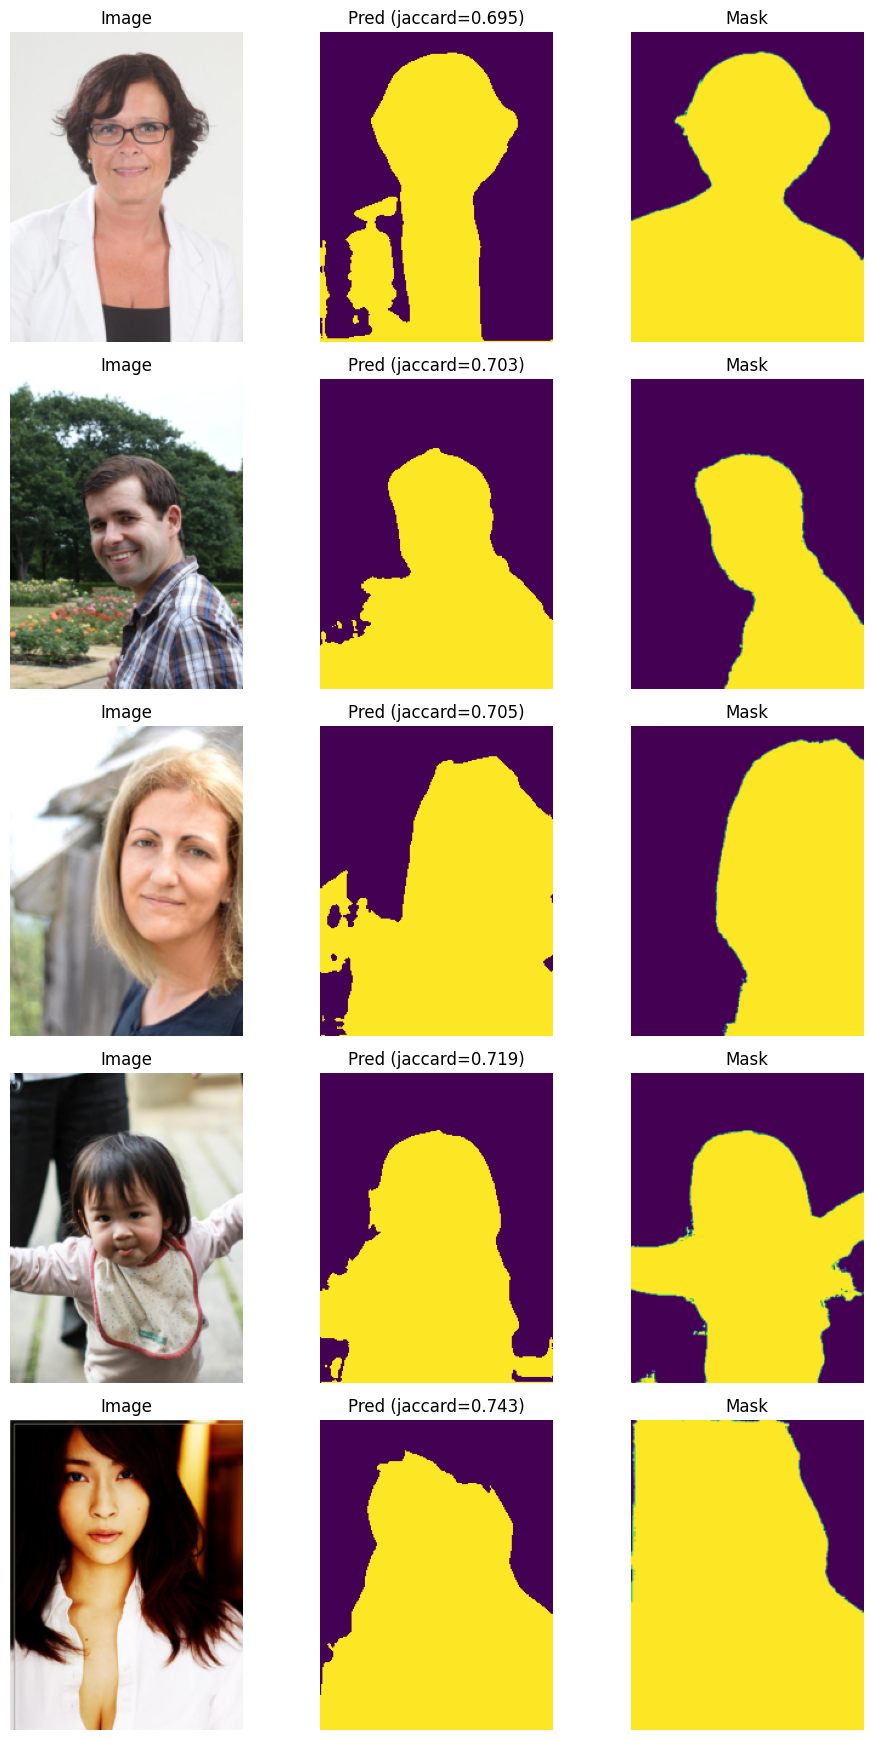

In [ ]:
test_images_all = torch.stack([img for img, _ in test_dataset])

visualize_from_tensors(test_images_all, test_masks_all,
                       ensemble_preds, ensemble_sample_scores, n_samples=5)

Топ-5 худших у ансамбля: jaccard 0.695–0.743. Проблемные случаи - белый фон сливается с одеждой, ребёнок с поднятыми руками, боковой ракурс, длинные волосы. Эти примеры встречались как сложные и у отдельных моделей.

### Перекрытие худших образцов

In [ ]:
TOP_N = 10
worst_ensemble_idx = set(np.argsort(ensemble_sample_scores)[:TOP_N])

print(f"Top-{TOP_N} worst samples (ensemble): {sorted(worst_ensemble_idx)}\n")

for i, scores in enumerate(fold_sample_scores):
    worst_fold_idx = set(np.argsort(scores)[:TOP_N])
    overlap = len(worst_ensemble_idx & worst_fold_idx)
    print(f"  Fold {i+1}: {overlap}/{TOP_N} совпадают  (худшие: {sorted(worst_fold_idx)})")

worst_single_idx   = set(np.argsort(single_sample_scores)[:TOP_N])
overlap_single = len(worst_ensemble_idx & worst_single_idx)
print(f"  Single: {overlap_single}/{TOP_N} совпадают  (худшие: {sorted(worst_single_idx)})")

Top-10 worst samples (ensemble): [np.int64(9), np.int64(33), np.int64(148), np.int64(218), np.int64(255), np.int64(283), np.int64(289), np.int64(325), np.int64(354), np.int64(372)]

  Fold 1: 7/10 совпадают  (худшие: [np.int64(9), np.int64(33), np.int64(57), np.int64(101), np.int64(148), np.int64(255), np.int64(289), np.int64(293), np.int64(325), np.int64(354)])
  Fold 2: 5/10 совпадают  (худшие: [np.int64(33), np.int64(57), np.int64(119), np.int64(148), np.int64(204), np.int64(255), np.int64(326), np.int64(341), np.int64(354), np.int64(372)])
  Fold 3: 8/10 совпадают  (худшие: [np.int64(33), np.int64(148), np.int64(202), np.int64(213), np.int64(218), np.int64(283), np.int64(289), np.int64(325), np.int64(354), np.int64(372)])
  Fold 4: 7/10 совпадают  (худшие: [np.int64(9), np.int64(33), np.int64(84), np.int64(148), np.int64(219), np.int64(255), np.int64(283), np.int64(316), np.int64(325), np.int64(354)])
  Fold 5: 8/10 совпадают  (худшие: [np.int64(9), np.int64(148), np.int64(212), np

### Предсказания по фолдам на худших семплах ансамбля

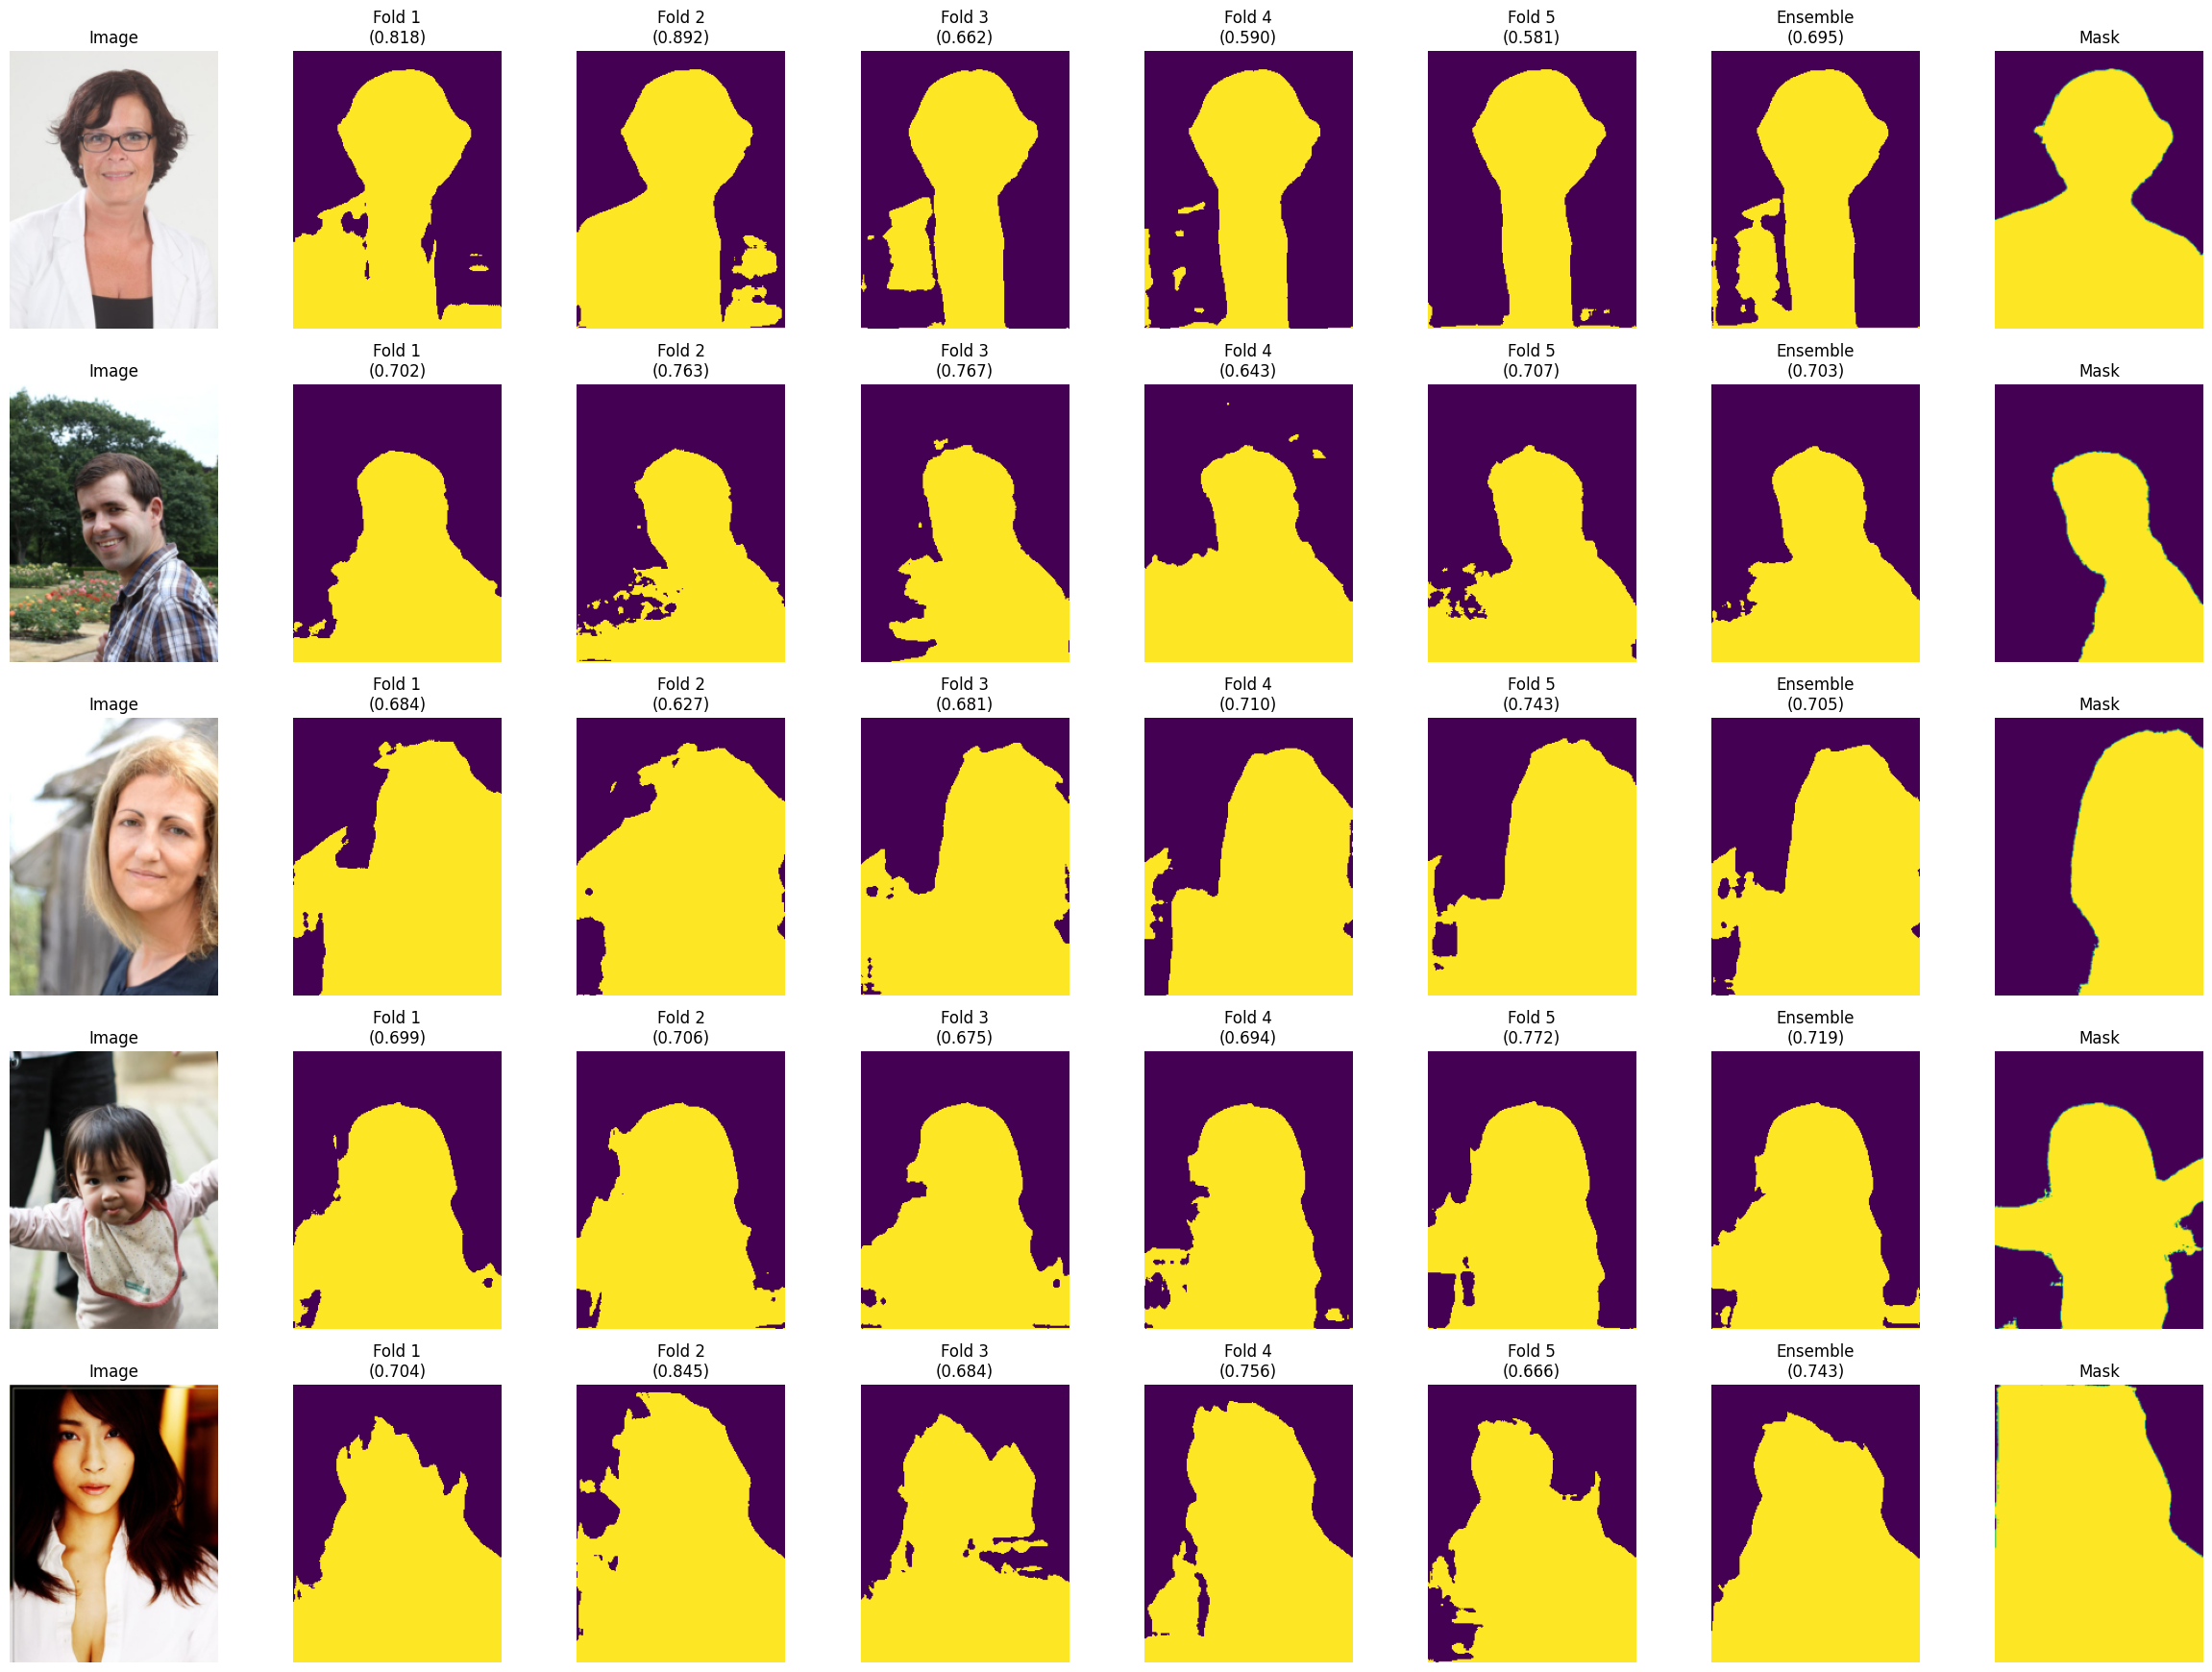

In [ ]:
def visualize_worst_across_folds(images, masks, fold_logits, ensemble_logits,
                                  ensemble_scores, n_samples=3):
    worst_idx = np.argsort(ensemble_scores)[:n_samples]
    n_cols = len(fold_logits) + 3  # image + folds + ensemble + mask

    fig, axes = plt.subplots(n_samples, n_cols, figsize=(3 * n_cols, 3.5 * n_samples))
    if n_samples == 1:
        axes = axes[np.newaxis, :]

    fold_scores_per_sample = [get_sample_scores(l, masks) for l in fold_logits]

    for row, idx in enumerate(worst_idx):
        img  = images[idx].permute(1, 2, 0).numpy()
        mask = masks[idx].squeeze().numpy()
        ens  = (torch.sigmoid(ensemble_logits[idx]).squeeze() > 0.5).numpy()

        col = 0
        axes[row, col].imshow(img);  axes[row, col].set_title("Image");  axes[row, col].axis('off')
        col += 1

        for f, fl in enumerate(fold_logits):
            pred  = (torch.sigmoid(fl[idx]).squeeze() > 0.5).numpy()
            score = fold_scores_per_sample[f][idx]
            axes[row, col].imshow(pred)
            axes[row, col].set_title(f"Fold {f+1}\n({score:.3f})")
            axes[row, col].axis('off')
            col += 1

        axes[row, col].imshow(ens)
        axes[row, col].set_title(f"Ensemble\n({ensemble_scores[idx]:.3f})")
        axes[row, col].axis('off')
        col += 1

        axes[row, col].imshow(mask); axes[row, col].set_title("Mask"); axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()


visualize_worst_across_folds(
    test_images_all, test_masks_all,
    logit_preds, ensemble_preds,
    ensemble_sample_scores, n_samples=5
)

Overlap худших семплов с ансамблем: фолды 3 и 5 совпадают на 8/10, фолды 1 и 4 - на 7/10, фолд 2 - на 5/10, single-модель - только на 4/10. Большинство проблемных семплов стабильно тяжёлые для всех моделей - то есть сложность определяется самим изображением, а не случайностью обучения. Ансамбль на этих примерах не даёт заметного преимущества: усреднение логитов не исправляет систематические ошибки, общие для всех фолдов.